# 03 - Eksperimen CNN (Skenario 10-11)

MobileNetV2 two-stage fine-tuning, Grad-CAM, McNemar vs S5.
- **S10** = SSR + E* + segmentasi (full pipeline klasik, diganti CNN)
- **S11** = tanpa restorasi, tanpa enhancement (baseline murni CNN vs S1 klasik)

In [1]:
# ============================================================
# Setup cell - Kaggle Notebooks (Kaggle-only). Jalankan PALING ATAS.
# Cara attach dataset: panel kanan > + Add Data > cari
#   'fruit and vegetable disease healthy vs rotten' > Add.
# ============================================================
import os
import warnings
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
import sys
import shutil
import subprocess
from pathlib import Path

# 1. Clone repo dari GitHub (atau pull jika sudah ada di sesi ini)
REPO_URL = "https://github.com/faizhuda/pcd-kelompok-17.git"
PROJECT_DIR = Path("/kaggle/working/pcd-kelompok-17")
if not PROJECT_DIR.exists():
    subprocess.run(["git", "clone", "--depth", "1", REPO_URL, str(PROJECT_DIR)], check=True)
else:
    subprocess.run(["git", "-C", str(PROJECT_DIR), "pull", "--ff-only"], check=False)

# 2. Working directory ke root project + tambah ke sys.path
os.chdir(PROJECT_DIR)
if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

# 3. Dependency inti SUDAH pre-installed di Kaggle -> tidak ada pip install.

# 4. Dataset gambar (read-only, hasil + Add Data)
# Auto-detect: Kaggle bisa mount di /kaggle/input/<slug> atau
# /kaggle/input/datasets/<user>/<slug> tergantung cara attach.
_DATASET_SLUG = 'fruit-and-vegetable-disease-healthy-vs-rotten'
_candidates = [
    Path('/kaggle/input') / _DATASET_SLUG,
    Path('/kaggle/input/datasets/muhammad0subhan') / _DATASET_SLUG,
]
RAW_DATA_DIR = next((p for p in _candidates if p.exists()), None)
if RAW_DATA_DIR is None:
    # Fallback: cari folder mana saja di /kaggle/input yang berisi gambar dataset
    for _p in Path('/kaggle/input').rglob(_DATASET_SLUG):
        if _p.is_dir():
            RAW_DATA_DIR = _p
            break
assert RAW_DATA_DIR is not None, "Dataset belum di-attach. + Add Data > cari dataset > Add."

# 5. Auto-restore hasil notebook sebelumnya (untuk notebook 03 & 04).
#    Attach output run lama via: + Add Data > Your Work / Dataset bersama.
def restore_previous_outputs():
    # Kaggle mounts notebook outputs di /kaggle/input/notebooks/<user>/<notebook>/
    # sehingga perlu rglob, bukan glob satu level.
    restored = []
    for repo in Path("/kaggle/input").rglob("pcd-kelompok-17"):
        if not repo.is_dir():
            continue
        for sub in ("results", "data/processed"):
            src_dir = repo / sub
            if src_dir.exists():
                shutil.copytree(src_dir, PROJECT_DIR / sub, dirs_exist_ok=True)
                restored.append(str(src_dir))
    return restored

restored = restore_previous_outputs()
print("Project :", PROJECT_DIR)
print("Dataset :", RAW_DATA_DIR)
print("Restore :", restored or "(mulai dari nol)")


Cloning into '/kaggle/working/pcd-kelompok-17'...


Project : /kaggle/working/pcd-kelompok-17
Dataset : /kaggle/input/datasets/muhammad0subhan/fruit-and-vegetable-disease-healthy-vs-rotten
Restore : ['/kaggle/input/notebooks/faiznaufalhuda/pcd-02-classical/pcd-kelompok-17/results', '/kaggle/input/notebooks/faiznaufalhuda/pcd-02-classical/pcd-kelompok-17/data/processed']


In [2]:
import os
import sys
from pathlib import Path

# Setup cell sudah chdir ke PROJECT_DIR & menambah sys.path (Kaggle-only).
ROOT = Path("/kaggle/working/pcd-kelompok-17")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.utils.class_weight import compute_class_weight

from src.evaluate import (
    append_significance_test,
    compute_metrics,
    make_gradcam_heatmap,
    mcnemar_test,
    plot_confusion_matrix,
    plot_gradcam,
    save_scenario_metrics,
)
from src.models import (
    build_mobilenetv2,
    compile_mobilenet,
    get_mobilenet_callbacks,
    unfreeze_last_layers,
)
from src.pipeline import image_to_cnn_input, process_image
from src.utils import build_dataset_index, get_project_paths, make_splits, read_best_enhancement, set_seed

set_seed(42)
paths = get_project_paths()
# Split di-regenerate dari dataset (deterministik) - identik dengan notebook 01/02
# RAW_DATA_DIR sudah di-set setup cell (auto-detect path Kaggle)
train_df, val_df, test_df = make_splits(build_dataset_index(RAW_DATA_DIR))
enhancement = read_best_enhancement(paths["metrics"])
print(f"Menggunakan enhancement E*: {enhancement}")


E0000 00:00:1781012259.375472      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781012259.436771      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781012259.898533      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781012259.898589      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781012259.898595      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781012259.898598      23 computation_placer.cc:177] computation placer already registered. Please check linka

Menggunakan enhancement E*: gamma


In [3]:
# Cache preprocessing ke disk (SSR + segmentasi dihitung sekali, bukan per epoch).
CACHE_DIR = Path('/kaggle/temp/tfcache')
CACHE_DIR.mkdir(parents=True, exist_ok=True)

def make_dataset(df, batch_size=32, shuffle=False,
                 restoration='ssr', do_segment=True,
                 enhancement_method=None, cache_name=None):
    if enhancement_method is None:
        enhancement_method = enhancement
    def generator():
        label_map = {"fresh": 0, "rotten": 1}
        for _, row in df.iterrows():
            out = process_image(
                path=row["filepath"],
                restoration=restoration,
                enhancement=enhancement_method,
                do_segment=do_segment,
            )
            if out["img"] is None:
                continue
            x = image_to_cnn_input(out["img"])[0]
            y = np.zeros(2, dtype=np.float32)
            y[label_map[row['label']]] = 1.0
            yield x, y

    dataset = tf.data.Dataset.from_generator(
        generator,
        output_signature=(
            tf.TensorSpec(shape=(224, 224, 3), dtype=tf.float32),
            tf.TensorSpec(shape=(2,), dtype=tf.float32),
        )
    )
    if cache_name is not None:
        dataset = dataset.cache(str(CACHE_DIR / cache_name))
    if shuffle:
        dataset = dataset.shuffle(buffer_size=2048, seed=42, reshuffle_each_iteration=True)
    return dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)

# S10: SSR + E* + segmentasi (identik dengan S5 klasik, tapi CNN)
train_ds_s10 = make_dataset(train_df, shuffle=True, restoration='ssr', do_segment=True, cache_name='train_s10')
val_ds_s10   = make_dataset(val_df,   restoration='ssr', do_segment=True, cache_name='val_s10')
test_ds_s10  = make_dataset(test_df,  restoration='ssr', do_segment=True, cache_name='test_s10')

# S11: tanpa restorasi, tanpa enhancement, tanpa segmentasi (baseline murni CNN)
train_ds_s11 = make_dataset(train_df, shuffle=True, restoration='none', do_segment=False, enhancement_method='none', cache_name='train_s11')
val_ds_s11   = make_dataset(val_df,   restoration='none', do_segment=False, enhancement_method='none', cache_name='val_s11')
test_ds_s11  = make_dataset(test_df,  restoration='none', do_segment=False, enhancement_method='none', cache_name='test_s11')


I0000 00:00:1781012698.911670      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [4]:
y_train_labels = train_df["label"].map({"fresh": 0, "rotten": 1}).values
classes = np.unique(y_train_labels)
weights = compute_class_weight("balanced", classes=classes, y=y_train_labels)
class_weight = {int(c): float(w) for c, w in zip(classes, weights)}
class_weight


{0: 1.0614707405489383, 1: 0.9452591772735658}

## Skenario 10: CNN - SSR + E* + Segmentasi (mirror S5)

### Stage 1 - Base frozen (20 epoch)

In [5]:
model_s10 = build_mobilenetv2(num_classes=2, use_augmentation=True)
model_s10 = compile_mobilenet(model_s10, learning_rate=1e-4)
cb_s10 = get_mobilenet_callbacks(str(paths["models"] / "mobilenetv2_s10_stage1.keras"))

history1_s10 = model_s10.fit(
    train_ds_s10, validation_data=val_ds_s10, epochs=20,
    class_weight=class_weight, callbacks=cb_s10,
)


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/20


I0000 00:00:1781012743.642121      77 cuda_dnn.cc:529] Loaded cuDNN version 91002


641/641 ━━━━━━━━━━━━━━━━━━━━ 429s 605ms/step - accuracy: 0.8442 - loss: 0.3544 - val_accuracy: 0.8526 - val_loss: 0.3191 - learning_rate: 1.0000e-04
Epoch 2/20
641/641 ━━━━━━━━━━━━━━━━━━━━ 57s 81ms/step - accuracy: 0.9037 - loss: 0.2372 - val_accuracy: 0.8855 - val_loss: 0.2619 - learning_rate: 1.0000e-04
Epoch 3/20
641/641 ━━━━━━━━━━━━━━━━━━━━ 58s 83ms/step - accuracy: 0.9229 - loss: 0.1988 - val_accuracy: 0.9105 - val_loss: 0.2249 - learning_rate: 1.0000e-04
Epoch 4/20
641/641 ━━━━━━━━━━━━━━━━━━━━ 41s 56ms/step - accuracy: 0.9326 - loss: 0.1718 - val_accuracy: 0.9207 - val_loss: 0.1969 - learning_rate: 1.0000e-04
Epoch 5/20
641/641 ━━━━━━━━━━━━━━━━━━━━ 37s 55ms/step - accuracy: 0.9381 - loss: 0.1581 - val_accuracy: 0.9248 - val_loss: 0.1842 - learning_rate: 1.0000e-04
Epoch 6/20
641/641 ━━━━━━━━━━━━━━━━━━━━ 36s 54ms/step - accuracy: 0.9446 - loss: 0.1419 - val_accuracy: 0.9341 - val_loss: 0.1683 - learning_rate: 1.0000e-04
Epoch 7/20
641/641 ━━━━━━━━━━━━━━━━━━━━ 36s 54ms/step - accur

### Stage 2 - Fine-tune 20 lapisan terakhir (50 epoch)

In [6]:
model_s10 = unfreeze_last_layers(model_s10, n=20)
model_s10 = compile_mobilenet(model_s10, learning_rate=1e-5)
cb2_s10 = get_mobilenet_callbacks(str(paths["models"] / "mobilenetv2_s10_stage2.keras"))

history2_s10 = model_s10.fit(
    train_ds_s10, validation_data=val_ds_s10, epochs=50,
    class_weight=class_weight, callbacks=cb2_s10,
)


Epoch 1/50
641/641 ━━━━━━━━━━━━━━━━━━━━ 56s 67ms/step - accuracy: 0.8917 - loss: 0.2761 - val_accuracy: 0.9571 - val_loss: 0.1141 - learning_rate: 1.0000e-05
Epoch 2/50
641/641 ━━━━━━━━━━━━━━━━━━━━ 41s 62ms/step - accuracy: 0.9174 - loss: 0.2039 - val_accuracy: 0.9548 - val_loss: 0.1205 - learning_rate: 1.0000e-05
Epoch 3/50
641/641 ━━━━━━━━━━━━━━━━━━━━ 41s 62ms/step - accuracy: 0.9307 - loss: 0.1721 - val_accuracy: 0.9557 - val_loss: 0.1146 - learning_rate: 1.0000e-05
Epoch 4/50
641/641 ━━━━━━━━━━━━━━━━━━━━ 42s 63ms/step - accuracy: 0.9392 - loss: 0.1519 - val_accuracy: 0.9637 - val_loss: 0.0989 - learning_rate: 1.0000e-05
Epoch 5/50
641/641 ━━━━━━━━━━━━━━━━━━━━ 42s 63ms/step - accuracy: 0.9469 - loss: 0.1373 - val_accuracy: 0.9646 - val_loss: 0.0930 - learning_rate: 1.0000e-05
Epoch 6/50
641/641 ━━━━━━━━━━━━━━━━━━━━ 42s 63ms/step - accuracy: 0.9506 - loss: 0.1251 - val_accuracy: 0.9680 - val_loss: 0.0890 - learning_rate: 1.0000e-05
Epoch 7/50
641/641 ━━━━━━━━━━━━━━━━━━━━ 41s 62ms/ste

### Visualisasi Kurva Belajar (S10)

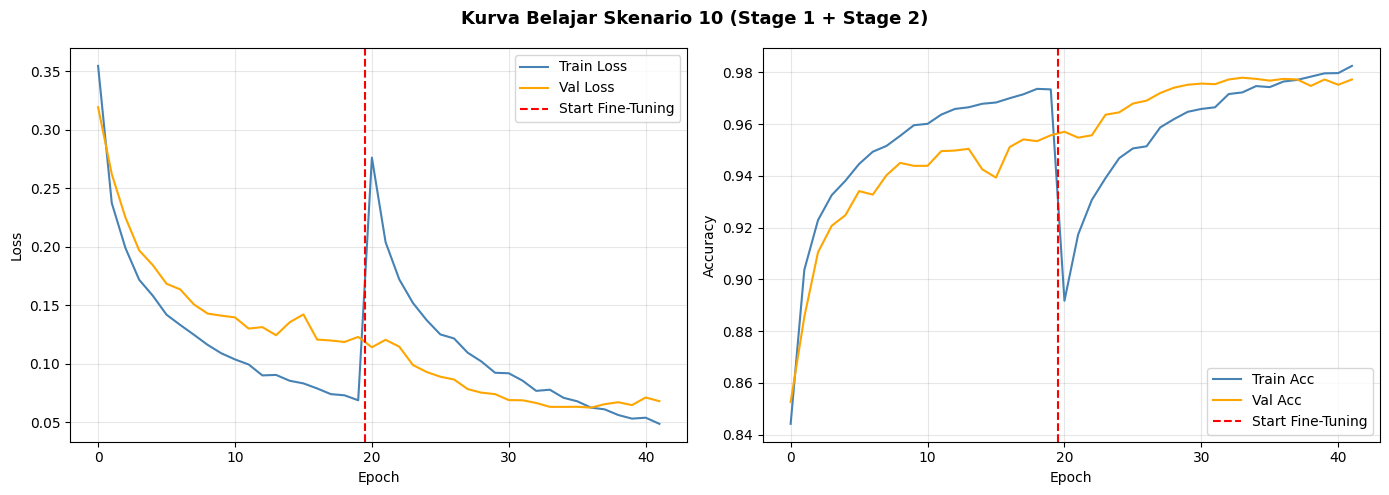

In [7]:
# Gabungkan history dari Stage 1 dan Stage 2
loss = history1_s10.history['loss'] + history2_s10.history['loss']
val_loss = history1_s10.history['val_loss'] + history2_s10.history['val_loss']
acc = history1_s10.history['accuracy'] + history2_s10.history['accuracy']
val_acc = history1_s10.history['val_accuracy'] + history2_s10.history['val_accuracy']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Kurva Belajar Skenario 10 (Stage 1 + Stage 2)', fontsize=13, fontweight='bold')

# Plot Loss
axes[0].plot(loss, label='Train Loss', color='steelblue')
axes[0].plot(val_loss, label='Val Loss', color='orange')
axes[0].axvline(len(history1_s10.history['loss']) - 0.5, color='red', linestyle='--', label='Start Fine-Tuning')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot Accuracy
axes[1].plot(acc, label='Train Acc', color='steelblue')
axes[1].plot(val_acc, label='Val Acc', color='orange')
axes[1].axvline(len(history1_s10.history['loss']) - 0.5, color='red', linestyle='--', label='Start Fine-Tuning')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(paths['figures'] / 'mobilenetv2_s10_learning_curve.png', dpi=150)
plt.show()


### Evaluasi Skenario 10

{'accuracy': 0.9722158961512184,
 'precision_weighted': 0.9724231384560226,
 'recall_weighted': 0.9722158961512184,
 'f1_weighted': 0.9722304040744569}

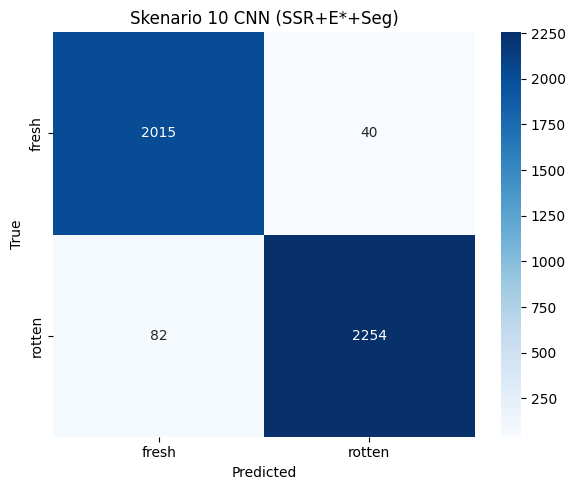

In [8]:
import time

# Collect valid rows during the evaluation loop (avoids a second
# full-dataset reprocessing pass that the old code did).
y_true_list, y_pred_list = [], []
valid_rows_s10 = []
t0 = time.perf_counter()
n = 0
for x_batch, y_batch in test_ds_s10:
    preds = model_s10.predict_on_batch(x_batch)
    y_pred_list.extend(np.argmax(preds, axis=1))
    y_true_list.extend(np.argmax(y_batch.numpy(), axis=1))
    n += len(y_batch)

infer_ms = (time.perf_counter() - t0) * 1000 / max(n, 1)
y_true_s10 = np.array(y_true_list)
y_pred_s10 = np.array(y_pred_list)
metrics_s10 = compute_metrics(y_true_s10, y_pred_s10)
save_scenario_metrics(
    10, enhancement, True, "cnn", "MobileNetV2",
    metrics_s10, infer_ms, len(y_true_s10), paths["metrics"], restoration="ssr",
)
# Build predictions CSV from test_df rows that match valid S10 generator order.
# The generator skips rows where process_image returns None; replicate same logic.
# Guarded: a length mismatch must NOT crash here (this cell runs BEFORE S11
# training, so a crash would waste the whole CNN run).
valid_rows_s10 = [
    row for _, row in test_df.iterrows()
    if process_image(row['filepath'], restoration='ssr', enhancement=enhancement, do_segment=True)['img'] is not None
]
if len(valid_rows_s10) == len(y_pred_s10):
    pred_df_s10 = pd.DataFrame(valid_rows_s10).reset_index(drop=True)
    pred_df_s10['pred'] = y_pred_s10
    pred_df_s10.to_csv(paths['metrics'] / 'predictions_s10.csv', index=False)
else:
    print(f'[WARN] predictions_s10 dilewati: {len(valid_rows_s10)} baris vs {len(y_pred_s10)} prediksi')
plot_confusion_matrix(y_true_s10, y_pred_s10, title="Skenario 10 CNN (SSR+E*+Seg)",
                      save_path=paths["figures_confusion"] / "scenario_10.png")
metrics_s10


## Skenario 11: CNN - Tanpa Restorasi, Tanpa Enhancement (mirror S1)

### Stage 1 - Base frozen (20 epoch)

In [9]:
model_s11 = build_mobilenetv2(num_classes=2, use_augmentation=True)
model_s11 = compile_mobilenet(model_s11, learning_rate=1e-4)
cb_s11 = get_mobilenet_callbacks(str(paths["models"] / "mobilenetv2_s11_stage1.keras"))

history1_s11 = model_s11.fit(
    train_ds_s11, validation_data=val_ds_s11, epochs=20,
    class_weight=class_weight, callbacks=cb_s11,
)


Epoch 1/20
641/641 ━━━━━━━━━━━━━━━━━━━━ 372s 525ms/step - accuracy: 0.8746 - loss: 0.3027 - val_accuracy: 0.9062 - val_loss: 0.2431 - learning_rate: 1.0000e-04
Epoch 2/20
641/641 ━━━━━━━━━━━━━━━━━━━━ 64s 90ms/step - accuracy: 0.9253 - loss: 0.1891 - val_accuracy: 0.9251 - val_loss: 0.1952 - learning_rate: 1.0000e-04
Epoch 3/20
641/641 ━━━━━━━━━━━━━━━━━━━━ 62s 88ms/step - accuracy: 0.9420 - loss: 0.1508 - val_accuracy: 0.9391 - val_loss: 0.1667 - learning_rate: 1.0000e-04
Epoch 4/20
641/641 ━━━━━━━━━━━━━━━━━━━━ 61s 88ms/step - accuracy: 0.9506 - loss: 0.1319 - val_accuracy: 0.9555 - val_loss: 0.1361 - learning_rate: 1.0000e-04
Epoch 5/20
641/641 ━━━━━━━━━━━━━━━━━━━━ 62s 88ms/step - accuracy: 0.9564 - loss: 0.1160 - val_accuracy: 0.9557 - val_loss: 0.1292 - learning_rate: 1.0000e-04
Epoch 6/20
641/641 ━━━━━━━━━━━━━━━━━━━━ 62s 89ms/step - accuracy: 0.9629 - loss: 0.1011 - val_accuracy: 0.9641 - val_loss: 0.1107 - learning_rate: 1.0000e-04
Epoch 7/20
641/641 ━━━━━━━━━━━━━━━━━━━━ 67s 95ms/s

### Stage 2 - Fine-tune 20 lapisan terakhir (50 epoch)

In [10]:
model_s11 = unfreeze_last_layers(model_s11, n=20)
model_s11 = compile_mobilenet(model_s11, learning_rate=1e-5)
cb2_s11 = get_mobilenet_callbacks(str(paths["models"] / "mobilenetv2_s11_stage2.keras"))

history2_s11 = model_s11.fit(
    train_ds_s11, validation_data=val_ds_s11, epochs=50,
    class_weight=class_weight, callbacks=cb2_s11,
)


Epoch 1/50
641/641 ━━━━━━━━━━━━━━━━━━━━ 78s 101ms/step - accuracy: 0.9139 - loss: 0.2245 - val_accuracy: 0.9528 - val_loss: 0.1230 - learning_rate: 1.0000e-05
Epoch 2/50
641/641 ━━━━━━━━━━━━━━━━━━━━ 69s 98ms/step - accuracy: 0.9408 - loss: 0.1532 - val_accuracy: 0.9682 - val_loss: 0.0847 - learning_rate: 1.0000e-05
Epoch 3/50
641/641 ━━━━━━━━━━━━━━━━━━━━ 68s 97ms/step - accuracy: 0.9501 - loss: 0.1316 - val_accuracy: 0.9705 - val_loss: 0.0776 - learning_rate: 1.0000e-05
Epoch 4/50
641/641 ━━━━━━━━━━━━━━━━━━━━ 68s 97ms/step - accuracy: 0.9566 - loss: 0.1112 - val_accuracy: 0.9714 - val_loss: 0.0750 - learning_rate: 1.0000e-05
Epoch 5/50
641/641 ━━━━━━━━━━━━━━━━━━━━ 68s 97ms/step - accuracy: 0.9620 - loss: 0.1000 - val_accuracy: 0.9748 - val_loss: 0.0650 - learning_rate: 1.0000e-05
Epoch 6/50
641/641 ━━━━━━━━━━━━━━━━━━━━ 68s 98ms/step - accuracy: 0.9677 - loss: 0.0904 - val_accuracy: 0.9764 - val_loss: 0.0608 - learning_rate: 1.0000e-05
Epoch 7/50
641/641 ━━━━━━━━━━━━━━━━━━━━ 67s 95ms/st

### Visualisasi Kurva Belajar (S11)

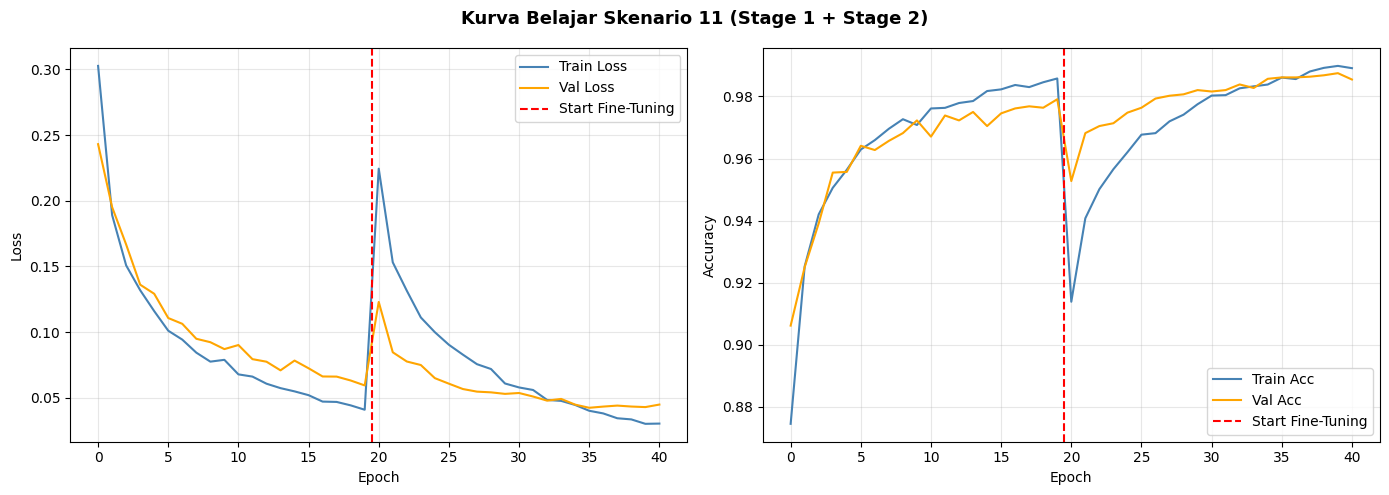

In [11]:
# Gabungkan history dari Stage 1 dan Stage 2
loss = history1_s11.history['loss'] + history2_s11.history['loss']
val_loss = history1_s11.history['val_loss'] + history2_s11.history['val_loss']
acc = history1_s11.history['accuracy'] + history2_s11.history['accuracy']
val_acc = history1_s11.history['val_accuracy'] + history2_s11.history['val_accuracy']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Kurva Belajar Skenario 11 (Stage 1 + Stage 2)', fontsize=13, fontweight='bold')

# Plot Loss
axes[0].plot(loss, label='Train Loss', color='steelblue')
axes[0].plot(val_loss, label='Val Loss', color='orange')
axes[0].axvline(len(history1_s11.history['loss']) - 0.5, color='red', linestyle='--', label='Start Fine-Tuning')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot Accuracy
axes[1].plot(acc, label='Train Acc', color='steelblue')
axes[1].plot(val_acc, label='Val Acc', color='orange')
axes[1].axvline(len(history1_s11.history['loss']) - 0.5, color='red', linestyle='--', label='Start Fine-Tuning')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(paths['figures'] / 'mobilenetv2_s11_learning_curve.png', dpi=150)
plt.show()


### Evaluasi Skenario 11

{'accuracy': 0.9870189023001594,
 'precision_weighted': 0.987062699762137,
 'recall_weighted': 0.9870189023001594,
 'f1_weighted': 0.9870222657764871}

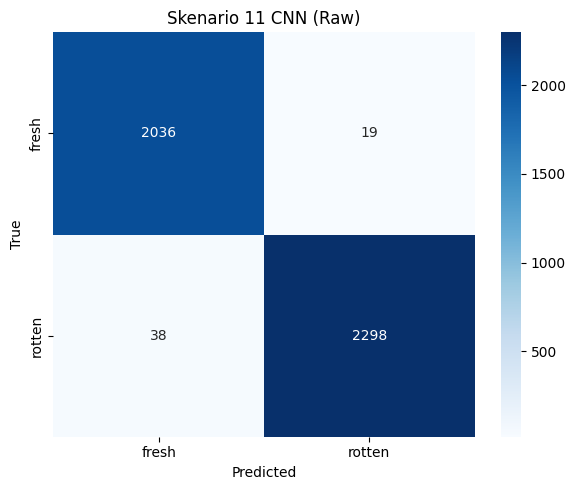

In [12]:
y_true_list, y_pred_list = [], []
t0 = time.perf_counter()
n = 0
for x_batch, y_batch in test_ds_s11:
    preds = model_s11.predict_on_batch(x_batch)
    y_pred_list.extend(np.argmax(preds, axis=1))
    y_true_list.extend(np.argmax(y_batch.numpy(), axis=1))
    n += len(y_batch)

infer_ms = (time.perf_counter() - t0) * 1000 / max(n, 1)
y_true_s11 = np.array(y_true_list)
y_pred_s11 = np.array(y_pred_list)
# Simpan hasil prediksi S11 untuk perbandingan komoditas di nb04
valid_rows_s11 = [
    row for _, row in test_df.iterrows()
    if process_image(row['filepath'], restoration='none', enhancement='none', do_segment=False)['img'] is not None
]
if len(valid_rows_s11) == len(y_pred_s11):
    pred_df_s11 = pd.DataFrame(valid_rows_s11).reset_index(drop=True)
    pred_df_s11['pred'] = y_pred_s11
    pred_df_s11.to_csv(paths['metrics'] / 'predictions_s11.csv', index=False)
else:
    print(f'[WARN] predictions_s11 dilewati: {len(valid_rows_s11)} baris vs {len(y_pred_s11)} prediksi')
metrics_s11 = compute_metrics(y_true_s11, y_pred_s11)
save_scenario_metrics(
    11, "none", False, "cnn", "MobileNetV2",
    metrics_s11, infer_ms, len(y_true_s11), paths["metrics"], restoration="none",
)
plot_confusion_matrix(y_true_s11, y_pred_s11, title="Skenario 11 CNN (Raw)",
                      save_path=paths["figures_confusion"] / "scenario_11.png")
metrics_s11


## McNemar Significance Tests (dijalankan sebelum Grad-CAM)


In [13]:
# McNemar bersifat SUPLEMENTER: metrik utama S10/S11 sudah tersimpan di sel
# sebelumnya. Seluruh blok dibungkus try/except agar error tak terduga di sini
# TIDAK memblokir Grad-CAM (traceback tetap dicetak supaya terlihat).
import traceback
import joblib

def _safe_mcnemar(name, a, b, y_t, p_a, p_b):
    # Guard panjang: McNemar butuh prediksi paired pada sampel yang sama.
    if len(p_a) != len(y_t) or len(p_b) != len(y_t):
        print(f'[SKIP {name}] panjang beda: y_true={len(y_t)}, {a}={len(p_a)}, {b}={len(p_b)}')
        return
    stat, pval, concl = mcnemar_test(y_t, p_a, p_b)
    append_significance_test(name, a, b, stat, pval, concl, paths['metrics'])
    print(f'{name}:', stat, pval, concl)

s5_path = paths['models'] / 'svm_scenario_05.pkl'
try:
    if not s5_path.exists():
        raise FileNotFoundError('svm_scenario_05.pkl tidak ada - jalankan nb02 dulu.')
    from src.experiments import extract_split_matrix
    from src.models import build_svm_pipeline
    enh = read_best_enhancement(paths['metrics'])

    # S5 (SVM full): fitur SSR+E*+seg+all - cache HIT dari nb02 (split_name='test').
    s5_model = joblib.load(s5_path)
    X_test_s5, _, _ = extract_split_matrix(
        test_df, enh, True, 'all', paths['data_processed'], split_name='test', restoration='ssr')
    y_pred_s5 = s5_model.predict(X_test_s5)

    # S1 (SVM raw): re-train cepat. PENTING - pakai y yang DIKEMBALIKAN extract
    # (label baris valid), bukan label_encode(train_df) penuh; kalau ada citra
    # tak terbaca panjangnya beda dan fit() akan crash.
    X_train_s1, y_train_s1, _ = extract_split_matrix(
        train_df, 'none', False, 'all', paths['data_processed'], split_name='train', restoration='none')
    X_test_s1, _, _ = extract_split_matrix(
        test_df, 'none', False, 'all', paths['data_processed'], split_name='test', restoration='none')
    s1_model = build_svm_pipeline()
    s1_model.fit(X_train_s1, y_train_s1)
    y_pred_s1 = s1_model.predict(X_test_s1)

    _safe_mcnemar('S10 vs S5 (CNN vs SVM)', 'S10', 'S5', y_true_s10, y_pred_s10, y_pred_s5)
    _safe_mcnemar('S11 vs S1 (CNN-raw vs SVM-raw)', 'S11', 'S1', y_true_s11, y_pred_s11, y_pred_s1)
    _safe_mcnemar('S10 vs S11 (full vs raw CNN)', 'S10', 'S11', y_true_s10, y_pred_s10, y_pred_s11)
except Exception:
    print('[McNemar dilewati karena error - metrik utama S10/S11 tetap aman]')
    traceback.print_exc()


Extracting features: 100%|██████████| 4391/4391 [04:08<00:00, 17.65it/s]


S10 vs S5 (CNN vs SVM): 324.37543252595157 1.6138277553259751e-72 signifikan
S11 vs S1 (CNN-raw vs SVM-raw): 151.8035087719298 6.994727712939899e-35 signifikan
S10 vs S11 (full vs raw CNN): 36.9009009009009 1.2428850544504146e-09 signifikan


## Grad-CAM (Skenario 10 - CNN full pipeline)

In [14]:
import matplotlib.pyplot as plt

gradcam_dir = paths["figures_gradcam"]
gradcam_dir.mkdir(parents=True, exist_ok=True)
representative = ["Apple", "Banana", "Tomato"]

for commodity in representative:
    for label in ["fresh", "rotten"]:
        subset = test_df[
            (test_df["commodity"].str.contains(commodity, case=False, na=False)) &
            (test_df["label"] == label)
        ]
        if subset.empty:
            subset = test_df[test_df["label"] == label].head(3)
        for _, row in subset.head(3).iterrows():
            out = process_image(
                path=row["filepath"], restoration="ssr",
                enhancement=enhancement, do_segment=True,
            )
            if out["img"] is None:
                continue
            x = image_to_cnn_input(out["img"])
            heatmap = make_gradcam_heatmap(model_s10, x)
            fname = Path(row["filepath"]).stem
            save = gradcam_dir / f"{commodity}_{label}_{fname}.png"
            plot_gradcam(out["img"], heatmap, save_path=save)
            plt.close("all")
